# Predicting 30-Day Hospital Readmission Risk Among Diabetic Emergency Admission Encounters Using Machine Learning

### Clinical Data Science Project

## Study Objective

To identify demographic, clinical, and healthcare utilization factors associated with 30-day readmission among diabetic inpatient encounters with emergency admission and construct a machine-learning-ready dataset for predictive modeling.

## Research Question

Which demographic, clinical, and healthcare utilization factors are associated with 30-day hospital readmission among diabetic inpatient encounters with emergency admission?

### Supporting Questions

- What factors are associated with increased readmission risk?
- Does previous healthcare utilization predict future readmission?
- Which features are most important for identifying high-risk patients?
- Which machine learning model provides the best predictive performance?

## Project Workflow

This project follows an end-to-end clinical data science workflow:

1. Connect to SQL Server
2. Extract the diabetes patient cohort
3. Explore the dataset
4. Clean and standardize the data
5. Validate data quality
6. Perform exploratory data analysis
7. Investigate readmission risk factors
8. Engineer features for machine learning
9. Build and evaluate predictive models
10. Summarize findings

## Tools Used

SQL Server

Python

Pandas

Jupyter Notebook

PyODBC

## Import Libraries

In [1]:
import pyodbc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## SQL Database Connection

The diabetes dataset is stored in Microsoft SQL Server. A connection is established using Python to retrieve patient encounter data for analysis.

In [2]:
conn = pyodbc.connect(
    "DRIVER={ODBC Driver 17 for SQL Server};"
    "SERVER=.\\SQLEXPRESS;"
    "DATABASE=diabetes_db;"
    "Trusted_Connection=yes;"
)

# Part 1: Data Extraction and Loading

The study cohort was extracted from the database using an SQL query and imported into a pandas DataFrame. The DataFrame serves as the primary dataset for all subsequent preprocessing, exploratory data analysis (EDA), feature engineering, visualization, and machine learning tasks.

In [3]:
query = "SELECT * FROM dbo.diabetes_data"
df = pd.read_sql(query, conn)

C:\Users\davon\AppData\Local\Temp\ipykernel_7152\2882961085.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


# Part 2: Data Understanding & Preparation

## 2.1 Understanding the Data

The dataset is inspected to verify successful extraction, review its structure, and identify potential data quality issues before cleaning.

In [4]:
df.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide_metformin,glipizide_metformin,glimepiride_pioglitazone,metformin_rosiglitazone,metformin_pioglitazone,change,diabetesMed,readmitted
0,12522,48330783,Caucasian,Female,[80-90),?,2,1,4,13,...,No,Steady,No,No,No,No,No,Ch,Yes,NO
1,15738,63555939,Caucasian,Female,[90-100),?,3,3,4,12,...,No,Steady,No,No,No,No,No,Ch,Yes,NO
2,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO
3,28236,89869032,AfricanAmerican,Female,[40-50),?,1,1,7,9,...,No,Steady,No,No,No,No,No,No,Yes,>30
4,35754,82637451,Caucasian,Male,[50-60),?,2,1,2,3,...,No,Steady,No,No,No,No,No,No,Yes,>30


In [5]:
df.shape

(101766, 50)

In [6]:
df.columns

Index(['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'weight',
       'admission_type_id', 'discharge_disposition_id', 'admission_source_id',
       'time_in_hospital', 'payer_code', 'medical_specialty',
       'num_lab_procedures', 'num_procedures', 'num_medications',
       'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1',
       'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult',
       'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide',
       'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide',
       'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone',
       'tolazamide', 'examide', 'citoglipton', 'insulin',
       'glyburide_metformin', 'glipizide_metformin',
       'glimepiride_pioglitazone', 'metformin_rosiglitazone',
       'metformin_pioglitazone', 'change', 'diabetesMed', 'readmitted'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      101766 non-null  object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    101766 non-null  object
 6   admission_type_id         101766 non-null  object
 7   discharge_disposition_id  101766 non-null  object
 8   admission_source_id       101766 non-null  object
 9   time_in_hospital          101766 non-null  object
 10  payer_code                101766 non-null  object
 11  medical_specialty         101766 non-null  object
 12  num_lab_procedures        101766 non-null  object
 13  num_procedures            101766 non-null  object
 14  num_

### Data Understanding Interpretation

- The dataset contains clinical patient records
- Target variable: readmitted
- Mix of numerical and categorical features

## 2.2 Summary Statistics

The following table provides a statistical summary of both numerical and categorical variables, including central tendency, dispersion, and frequency distribution.

In [8]:
df.describe(include="all")

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide_metformin,glipizide_metformin,glimepiride_pioglitazone,metformin_rosiglitazone,metformin_pioglitazone,change,diabetesMed,readmitted
count,1.017660e+05,1.017660e+05,101766,101766,101766,101766,101766,101766,101766,101766,...,101766,101766,101766,101766,101766,101766,101766,101766,101766,101766
unique,NaN,NaN,6,3,10,10,8,26,17,14,...,1,4,4,2,2,2,2,2,2,3
top,NaN,NaN,Caucasian,Female,[70-80),?,1,1,7,3,...,No,No,No,No,No,No,No,No,Yes,NO
freq,NaN,NaN,76099,54708,26068,98569,53990,60234,57494,17756,...,101766,47383,101060,101753,101765,101764,101765,54755,78363,54864
mean,1.652016e+08,5.433040e+07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,1.026403e+08,3.869636e+07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,1.252200e+04,1.350000e+02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,8.496119e+07,2.341322e+07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,1.523890e+08,4.550514e+07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,2.302709e+08,8.754595e+07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Key Observations:

* The dataset contains **101,766 patient encounters and 50 features** representing demographic, clinical, medication, and hospital-related information.

* The data includes both **categorical and numerical variables**, with several categorical features requiring preprocessing before modeling.

* Demographic analysis shows the majority of patients are **Caucasian, female, and within older age groups ([70-80))**.

* Several medication variables are highly imbalanced, with most patients recorded as **"No"** for specific medications.

* The target variable **`readmitted` contains three classes and shows class imbalance**, with "NO" being the most common outcome.

* Missing values are represented as **"?"**, requiring cleaning and appropriate handling before feature engineering and modeling.

* Identifier variables (**`encounter_id` and `patient_nbr`**) should be evaluated for removal because they may not provide predictive clinical value.

### 2.2 Data Quality Check

This section evaluates the dataset for missing values, duplicate records, unique value counts, and inconsistent data entries to assess data integrity prior to feature engineering and modeling.

In [9]:
df.isna().sum()

encounter_id                0
patient_nbr                 0
race                        0
gender                      0
age                         0
weight                      0
admission_type_id           0
discharge_disposition_id    0
admission_source_id         0
time_in_hospital            0
payer_code                  0
medical_specialty           0
num_lab_procedures          0
num_procedures              0
num_medications             0
number_outpatient           0
number_emergency            0
number_inpatient            0
diag_1                      0
diag_2                      0
diag_3                      0
number_diagnoses            0
max_glu_serum               0
A1Cresult                   0
metformin                   0
repaglinide                 0
nateglinide                 0
chlorpropamide              0
glimepiride                 0
acetohexamide               0
glipizide                   0
glyburide                   0
tolbutamide                 0
pioglitazo

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.nunique()

encounter_id                101766
patient_nbr                  71518
race                             6
gender                           3
age                             10
weight                          10
admission_type_id                8
discharge_disposition_id        26
admission_source_id             17
time_in_hospital                14
payer_code                      18
medical_specialty               73
num_lab_procedures             118
num_procedures                   7
num_medications                 75
number_outpatient               39
number_emergency                33
number_inpatient                21
diag_1                         717
diag_2                         749
diag_3                         790
number_diagnoses                16
max_glu_serum                    4
A1Cresult                        4
metformin                        4
repaglinide                      4
nateglinide                      4
chlorpropamide                   4
glimepiride         

In [12]:
(df=="?").sum()

encounter_id                    0
patient_nbr                     0
race                         2273
gender                          0
age                             0
weight                      98569
admission_type_id               0
discharge_disposition_id        0
admission_source_id             0
time_in_hospital                0
payer_code                  40256
medical_specialty           49949
num_lab_procedures              0
num_procedures                  0
num_medications                 0
number_outpatient               0
number_emergency                0
number_inpatient                0
diag_1                         21
diag_2                        358
diag_3                       1423
number_diagnoses                0
max_glu_serum                   0
A1Cresult                       0
metformin                       0
repaglinide                     0
nateglinide                     0
chlorpropamide                  0
glimepiride                     0
acetohexamide 

### Data Quality Assessment Summary

- Checked missing values (NaN and "?")
- Checked duplicate rows
- Checked unique values per column
- Inspected data types and structure

## 2.3 Data Standardization

Variables are standardized to ensure consistent naming conventions, appropriate data types, and clinically meaningful categories throughout the analysis.

In [13]:
df.rename(columns={
    "A1Cresult": "a1c_result",
    "diabetesMed": "diabetes_medication", "change":"change_medication", "num_lab_procedures":"number_lab_procedures",
    "num_procedures":"number_procedures", "num_medications":"number_medications","number_inpatient":"number_inpatient_visits"
}, inplace=True)

df.columns


Index(['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'weight',
       'admission_type_id', 'discharge_disposition_id', 'admission_source_id',
       'time_in_hospital', 'payer_code', 'medical_specialty',
       'number_lab_procedures', 'number_procedures', 'number_medications',
       'number_outpatient', 'number_emergency', 'number_inpatient_visits',
       'diag_1', 'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum',
       'a1c_result', 'metformin', 'repaglinide', 'nateglinide',
       'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide',
       'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose',
       'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton',
       'insulin', 'glyburide_metformin', 'glipizide_metformin',
       'glimepiride_pioglitazone', 'metformin_rosiglitazone',
       'metformin_pioglitazone', 'change_medication', 'diabetes_medication',
       'readmitted'],
      dtype='object')

In [14]:
df.replace(["?", "NA", "N/A"],np.nan,inplace=True)

In [15]:
(df == "?").sum()

encounter_id                0
patient_nbr                 0
race                        0
gender                      0
age                         0
weight                      0
admission_type_id           0
discharge_disposition_id    0
admission_source_id         0
time_in_hospital            0
payer_code                  0
medical_specialty           0
number_lab_procedures       0
number_procedures           0
number_medications          0
number_outpatient           0
number_emergency            0
number_inpatient_visits     0
diag_1                      0
diag_2                      0
diag_3                      0
number_diagnoses            0
max_glu_serum               0
a1c_result                  0
metformin                   0
repaglinide                 0
nateglinide                 0
chlorpropamide              0
glimepiride                 0
acetohexamide               0
glipizide                   0
glyburide                   0
tolbutamide                 0
pioglitazo

In [16]:
race_map = {
    "Caucasian": "White",
    "AfricanAmerican": "Black",
    "asian": "Asian",
    "other": "Other",
    "hispanic": "Hispanic"
}

df["race"] = df["race"].replace(race_map)
df["race"].unique()

array(['White', 'Black', nan, 'Other', 'Asian', 'Hispanic'], dtype=object)

In [17]:
num_cols = [
    "time_in_hospital",
    "number_lab_procedures",
    "number_procedures",
    "number_medications",
    "number_outpatient",
    "number_emergency",
    "number_inpatient_visits",
    "number_diagnoses"
]

df[num_cols] = df[num_cols].astype(int)
df.dtypes

encounter_id                 int64
patient_nbr                  int64
race                        object
gender                      object
age                         object
weight                      object
admission_type_id           object
discharge_disposition_id    object
admission_source_id         object
time_in_hospital             int64
payer_code                  object
medical_specialty           object
number_lab_procedures        int64
number_procedures            int64
number_medications           int64
number_outpatient            int64
number_emergency             int64
number_inpatient_visits      int64
diag_1                      object
diag_2                      object
diag_3                      object
number_diagnoses             int64
max_glu_serum               object
a1c_result                  object
metformin                   object
repaglinide                 object
nateglinide                 object
chlorpropamide              object
glimepiride         

In [18]:
age_map = {

    "[0-10)": 5,
    "[10-20)": 15,
    "[20-30)": 25,
    "[30-40)": 35,
    "[40-50)": 45,
    "[50-60)": 55,
    "[60-70)": 65,
    "[70-80)": 75,
    "[80-90)": 85,
    "[90-100)": 95
}

df["age"] = df["age"].replace(age_map)
df["age"] = df["age"].astype("int64")

C:\Users\davon\AppData\Local\Temp\ipykernel_7152\2540490538.py:15: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["age"] = df["age"].replace(age_map)


In [19]:
cat_cols = [
    "race", "gender",
    "admission_type_id",
    "discharge_disposition_id",
    "admission_source_id",
    "change_medication",
    "diabetes_med",
    "readmitted",
    "insulin",
]

cat_cols = [col for col in cat_cols if col in df.columns]

df[cat_cols] = df[cat_cols].astype("category")

In [20]:
df["diag_1"] = pd.to_numeric(df["diag_1"], errors="coerce")
df["diag_2"] = pd.to_numeric(df["diag_2"], errors="coerce")
df["diag_3"] = pd.to_numeric(df["diag_3"], errors="coerce")

In [21]:
df["diag_1_group"] = "Other"
df.loc[(df["diag_1"] >= 250) & (df["diag_1"] < 251), "diag_1_group"] = "Diabetes"
df.loc[(df["diag_1"] >= 401) & (df["diag_1"] < 405), "diag_1_group"] = "Hypertension"
df.loc[(df["diag_1"] >= 414) & (df["diag_1"] < 416), "diag_1_group"] = "Heart_Disease"

df["diag_2_group"] = "Other"
df.loc[(df["diag_2"] >= 250) & (df["diag_2"] < 251), "diag_2_group"] = "Diabetes"
df.loc[(df["diag_2"] >= 401) & (df["diag_2"] < 405), "diag_2_group"] = "Hypertension"
df.loc[(df["diag_2"] >= 414) & (df["diag_2"] < 416), "diag_2_group"] = "Heart_Disease"

df["diag_3_group"] = "Other"
df.loc[(df["diag_3"] >= 250) & (df["diag_3"] < 251), "diag_3_group"] = "Diabetes"
df.loc[(df["diag_3"] >= 401) & (df["diag_3"] < 405), "diag_3_group"] = "Hypertension"
df.loc[(df["diag_3"] >= 414) & (df["diag_3"] < 416), "diag_3_group"] = "Heart_Disease"

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 53 columns):
 #   Column                    Non-Null Count   Dtype   
---  ------                    --------------   -----   
 0   encounter_id              101766 non-null  int64   
 1   patient_nbr               101766 non-null  int64   
 2   race                      99493 non-null   category
 3   gender                    101766 non-null  category
 4   age                       101766 non-null  int64   
 5   weight                    3197 non-null    object  
 6   admission_type_id         101766 non-null  category
 7   discharge_disposition_id  101766 non-null  category
 8   admission_source_id       101766 non-null  category
 9   time_in_hospital          101766 non-null  int64   
 10  payer_code                61510 non-null   object  
 11  medical_specialty         51817 non-null   object  
 12  number_lab_procedures     101766 non-null  int64   
 13  number_procedures         101

In [23]:
df.columns

Index(['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'weight',
       'admission_type_id', 'discharge_disposition_id', 'admission_source_id',
       'time_in_hospital', 'payer_code', 'medical_specialty',
       'number_lab_procedures', 'number_procedures', 'number_medications',
       'number_outpatient', 'number_emergency', 'number_inpatient_visits',
       'diag_1', 'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum',
       'a1c_result', 'metformin', 'repaglinide', 'nateglinide',
       'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide',
       'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose',
       'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton',
       'insulin', 'glyburide_metformin', 'glipizide_metformin',
       'glimepiride_pioglitazone', 'metformin_rosiglitazone',
       'metformin_pioglitazone', 'change_medication', 'diabetes_medication',
       'readmitted', 'diag_1_group', 'diag_2_group', 'diag_3_group'],


### Data Standardization Interpretation:

* The dataset has been successfully standardized, improving consistency and interpretability of clinical variables.

* Categorical values were reviewed and standardized, including race categories and missing value representations.

* ICD diagnosis features ('diag_1,' 'diag_2,' and 'diag_3') were transformed into grouped clinical categories to improve model interpretability and reduce feature complexity.

* Column names were standardized to improve readability and maintain consistency throughout the analysis workflow.

* These transformations created a cleaner dataset that is better prepared for data cleaning, exploratory analysis, and machine learning preparation.

* The next steps will focus on validating data quality, addressing remaining missing values, encoding categorical variables, and preparing features for predictive modeling.

# Part 3 :Data Cleaning

Clinical datasets often contain missing values, inconsistent categories, and incorrect data types. Cleaning improves data quality and prepares the dataset for analysis and machine learning.

In [24]:
df[["diag_1", "diag_2", "diag_3"]].isna().sum()

diag_1    1666
diag_2    2894
diag_3    6481
dtype: int64

In [25]:
df.replace(998, np.nan, inplace=True)

In [26]:
df["diag_1"] = df["diag_1"].fillna("Unknown")
df["diag_2"] = df["diag_2"].fillna("Unknown")
df["diag_3"] = df["diag_3"].fillna("Unknown")

df[["diag_1", "diag_2", "diag_3"]].isna().sum()

diag_1    0
diag_2    0
diag_3    0
dtype: int64

In [27]:
df.drop(columns=[
    'weight', 'payer_code', 'medical_specialty', 'number_outpatient',
    'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide',
    'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide',
    'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone',
    'tolazamide', 'examide', 'citoglipton', 'glyburide_metformin',
    'glipizide_metformin', 'glimepiride_pioglitazone',
    'metformin_rosiglitazone', 'metformin_pioglitazone',
    'discharge_disposition_id'
], inplace=True, errors='ignore')

df.columns

Index(['encounter_id', 'patient_nbr', 'race', 'gender', 'age',
       'admission_type_id', 'admission_source_id', 'time_in_hospital',
       'number_lab_procedures', 'number_procedures', 'number_medications',
       'number_emergency', 'number_inpatient_visits', 'diag_1', 'diag_2',
       'diag_3', 'number_diagnoses', 'max_glu_serum', 'a1c_result', 'insulin',
       'change_medication', 'diabetes_medication', 'readmitted',
       'diag_1_group', 'diag_2_group', 'diag_3_group'],
      dtype='object')

### Data Cleaning Interpretation:

* Removed variables with substantial missing data (e.g., 'weight,' 'payer_code,' and `medical_specialty') because they were unlikely to provide reliable predictive information.

* Removed medication-specific variables due to high sparsity and limited expected contribution to the predictive model.

* Excluded `number_outpatients' to maintain focus on inpatient encounter-related factors.

* Removed `discharge_disposition_id' to reduce potential data leakage risk because it may contain information only available after or during the discharge process.

* These feature reduction steps improved data quality, reduced dataset complexity, and created a more interpretable dataset for exploratory analysis and machine learning.

 # Part 4: Data Validation

After cleaning and standardization, the dataset is validated to confirm that transformations were applied correctly and that the data are ready for analysis.

In [28]:
df.isna().sum()

encounter_id                  0
patient_nbr                   0
race                       2273
gender                        0
age                           0
admission_type_id             0
admission_source_id           0
time_in_hospital              0
number_lab_procedures         0
number_procedures             0
number_medications            0
number_emergency              0
number_inpatient_visits       0
diag_1                        0
diag_2                        0
diag_3                        0
number_diagnoses              0
max_glu_serum                 0
a1c_result                    0
insulin                       0
change_medication             0
diabetes_medication           0
readmitted                    0
diag_1_group                  0
diag_2_group                  0
diag_3_group                  0
dtype: int64

In [29]:
df["race"] = df["race"].cat.add_categories(["Unknown"])
df["race"] = df["race"].fillna("Unknown")

df["race"].isna().sum()

np.int64(0)

In [30]:
df.dtypes

encounter_id                  int64
patient_nbr                   int64
race                       category
gender                     category
age                           int64
admission_type_id          category
admission_source_id        category
time_in_hospital              int64
number_lab_procedures         int64
number_procedures             int64
number_medications            int64
number_emergency              int64
number_inpatient_visits       int64
diag_1                       object
diag_2                       object
diag_3                       object
number_diagnoses              int64
max_glu_serum                object
a1c_result                   object
insulin                    category
change_medication          category
diabetes_medication          object
readmitted                 category
diag_1_group                 object
diag_2_group                 object
diag_3_group                 object
dtype: object

In [31]:
df.shape

(101766, 26)

In [32]:
df.describe()

,encounter_id,patient_nbr,age,time_in_hospital,number_lab_procedures,number_procedures,number_medications,number_emergency,number_inpatient_visits,number_diagnoses
count,1.017660e+05,1.017660e+05,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000
mean,1.652016e+08,5.433040e+07,65.967022,4.395987,43.095641,1.339730,16.021844,0.197836,0.635566,7.422607
std,1.026403e+08,3.869636e+07,15.940838,2.985108,19.674362,1.705807,8.127566,0.930472,1.262863,1.933600
min,1.252200e+04,1.350000e+02,5.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,1.000000
25%,8.496119e+07,2.341322e+07,55.000000,2.000000,31.000000,0.000000,10.000000,0.000000,0.000000,6.000000
50%,1.523890e+08,4.550514e+07,65.000000,4.000000,44.000000,1.000000,15.000000,0.000000,0.000000,8.000000
75%,2.302709e+08,8.754595e+07,75.000000,6.000000,57.000000,2.000000,20.000000,0.000000,1.000000,9.000000
max,4.438672e+08,1.895026e+08,95.000000,14.000000,132.000000,6.000000,81.000000,76.000000,21.000000,16.000000


In [33]:
df["race"].unique()
df["gender"].unique()
df["age"].unique()

(df == "?").sum()

encounter_id               0
patient_nbr                0
race                       0
gender                     0
age                        0
admission_type_id          0
admission_source_id        0
time_in_hospital           0
number_lab_procedures      0
number_procedures          0
number_medications         0
number_emergency           0
number_inpatient_visits    0
diag_1                     0
diag_2                     0
diag_3                     0
number_diagnoses           0
max_glu_serum              0
a1c_result                 0
insulin                    0
change_medication          0
diabetes_medication        0
readmitted                 0
diag_1_group               0
diag_2_group               0
diag_3_group               0
dtype: int64

### Data Validation Interpretation:

* Missing value checks confirmed that most variables contain **no remaining missing values** after data cleaning.

* The `race` feature initially contained **2,273 missing values**, which were successfully replaced with an **"Unknown" category** to preserve patient records.

* Diagnosis variables (**`diag_1`, `diag_2`, and **`diag_3`**) were validated after replacing missing entries represented by **`?`** with **"Unknown," resulting in no remaining missing values.

* Data standardization steps were verified to ensure categorical variables contained consistent labels and formatting.

* Data types and unique value counts were reviewed to identify potential issues before feature engineering and machine learning.

* The cleaned dataset is now ready for the next stage of the workflow

## Save Clean Dataset to Jupyter File

In [34]:
df.to_csv('diabetes_clean.csv', index=False)
print("Data saved to CSV file!")

Data saved to CSV file!


## Save Clean Dataset to SQL Server

In [35]:
from sqlalchemy import create_engine
import urllib.parse

In [36]:
connection_string = (
    "DRIVER={ODBC Driver 17 for SQL Server};"
    "SERVER=.\\SQLEXPRESS;"
    "DATABASE=diabetes_db;"
    "Trusted_Connection=yes;"
)

connection_url = urllib.parse.quote_plus(connection_string)

engine = create_engine(
    f"mssql+pyodbc:///?odbc_connect={connection_url}"
)

In [37]:
df.to_sql(
    name="diabetes_data_clean",
    con=engine,
    if_exists="replace",
    index=False
)

C:\Users\davon\New folder\Lib\site-packages\pandas\io\sql.py:1648: SAWarning: Unrecognized server version info '17.0.1000.7'.  Some SQL Server features may not function properly.
  con = self.exit_stack.enter_context(con.connect())


6

## Data Preparation Summary

The dataset was successfully cleaned, standardized, and validated for downstream analysis. Missing values were handled appropriately, categorical variables were standardized for consistency, and diagnosis codes were grouped into clinically meaningful categories through ICD-based feature engineering. Variables with excessive missingness, limited analytical value, or potential for data leakage were removed to improve data quality and model reliability. The cleaned dataset was validated to ensure all transformations were applied correctly and was then saved in two locations:

* **Jupyter Notebook Project Folder:** `diabetes_data_clean.csv`
* **SQL Server:** `dbo.diabetes_data_clean`

Saving the cleaned dataset in both locations provides a reproducible analytical dataset that can be used for SQL cohort extraction, exploratory data analysis, feature engineering, and machine learning without modifying the original raw data.

# Part 5: SQL Cohort Extraction (SQL)

This cohort definition ensures the analysis focuses specifically on acute diabetes-related hospital encounters rather than all diabetes patients.

In [38]:
query="""
SELECT*
FROM dbo.diabetes_data_clean
WHERE (
diag_1 LIKE '250%'OR 
diag_2 LIKE '250%'OR 
diag_3 LIKE '250%'
)
AND admission_type_id=1
"""
df = pd.read_sql(query,conn)
df.head()

C:\Users\davon\AppData\Local\Temp\ipykernel_7152\1525260284.py:11: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query,conn)


,encounter_id,patient_nbr,race,gender,age,admission_type_id,admission_source_id,time_in_hospital,number_lab_procedures,number_procedures,...,number_diagnoses,max_glu_serum,a1c_result,insulin,change_medication,diabetes_medication,readmitted,diag_1_group,diag_2_group,diag_3_group
0,16680,42519267,White,Male,45,1,7,1,51,0,...,5,None,None,Steady,Ch,Yes,NO,Other,Other,Diabetes
1,28236,89869032,Black,Female,45,1,7,9,47,2,...,9,None,None,Steady,No,Yes,>30,Diabetes,Hypertension,Other
2,40926,85504905,White,Female,45,1,7,7,60,0,...,8,None,None,Down,Ch,Yes,<30,Other,Diabetes,Diabetes
3,63768,114882984,White,Male,75,1,7,5,73,0,...,8,None,None,No,No,Yes,>30,Other,Other,Diabetes
4,64410,86047875,Black,Female,25,1,7,2,11,5,...,6,None,None,No,No,Yes,NO,Other,Diabetes,Other


In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19689 entries, 0 to 19688
Data columns (total 26 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   encounter_id             19689 non-null  int64 
 1   patient_nbr              19689 non-null  int64 
 2   race                     19689 non-null  object
 3   gender                   19689 non-null  object
 4   age                      19689 non-null  int64 
 5   admission_type_id        19689 non-null  object
 6   admission_source_id      19689 non-null  object
 7   time_in_hospital         19689 non-null  int64 
 8   number_lab_procedures    19689 non-null  int64 
 9   number_procedures        19689 non-null  int64 
 10  number_medications       19689 non-null  int64 
 11  number_emergency         19689 non-null  int64 
 12  number_inpatient_visits  19689 non-null  int64 
 13  diag_1                   19689 non-null  object
 14  diag_2                   19689 non-nul

In [40]:
df.columns

Index(['encounter_id', 'patient_nbr', 'race', 'gender', 'age',
       'admission_type_id', 'admission_source_id', 'time_in_hospital',
       'number_lab_procedures', 'number_procedures', 'number_medications',
       'number_emergency', 'number_inpatient_visits', 'diag_1', 'diag_2',
       'diag_3', 'number_diagnoses', 'max_glu_serum', 'a1c_result', 'insulin',
       'change_medication', 'diabetes_medication', 'readmitted',
       'diag_1_group', 'diag_2_group', 'diag_3_group'],
      dtype='object')

## SQL Cohort Extraction Interpretation

The study cohort consists of emergency hospital encounters involving patients with diabetes-related diagnoses. Diabetes cases were identified using ICD-9 diagnosis codes beginning with **"250 %"** appearing in any of the primary diagnosis fields (**diag_1, diag_2, or diag_3**). The cohort was further restricted to emergency admissions (**admission_type_id = 1**) to focus on acute care presentations.

After applying these inclusion criteria, the extracted dataset contained **19,689 hospital encounters and 26 clinical and utilization-related variables**. Each row represents an individual hospital encounter, while patient_nbr allows identification of repeated encounters from the same patient. This encounter-level structure supports analysis of healthcare utilization patterns and development of predictive models for diabetes-related readmission risk.

# Part 6: Cohort Analysis

This section summarizes baseline demographic characteristics and healthcare utilization patterns within the diabetic inpatient cohort. 

## 6.1 Demographic Characteristics

Understanding patient demographics provides important context about the population included in this study. 
Age, gender, and race distributions were examined to identify the characteristics of patients hospitalized with diabetes.

This analysis helps answer:

**Who are the patients represented in this dataset, and what demographic groups are most common among hospitalized diabetic patients?**

In [41]:
df["age"].value_counts(normalize=True) * 100

age
55    19.493118
75    19.305196
65    18.675403
45    14.622378
85    12.052415
35     7.176596
25     4.027630
15     2.128092
95     1.985880
5      0.533293
Name: proportion, dtype: float64

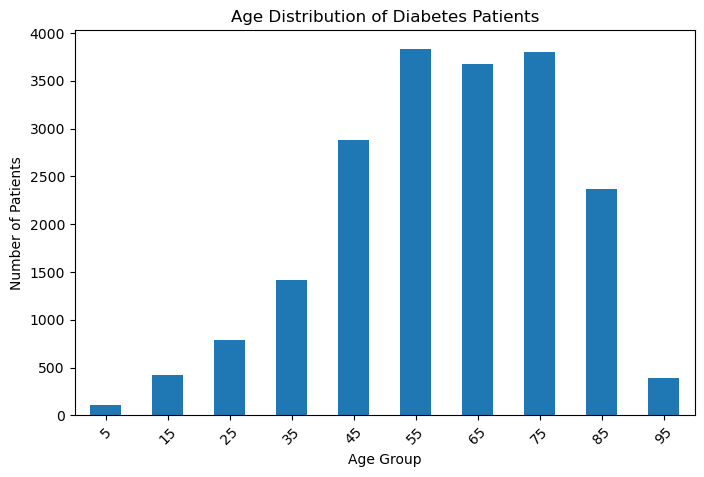

In [42]:
plt.figure(figsize=(8,5))

df["age"].value_counts().sort_index().plot(kind="bar")

plt.title("Age Distribution of Diabetes Patients")
plt.xlabel("Age Group")
plt.ylabel("Number of Patients")
plt.xticks(rotation=45)

plt.show()

In [43]:
df["gender"].value_counts(normalize=True) * 100

gender
Female    54.416171
Male      45.583829
Name: proportion, dtype: float64

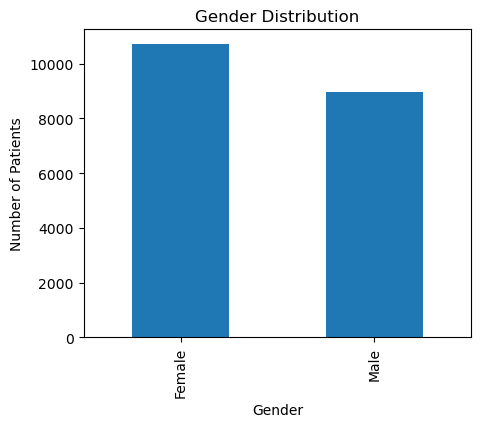

In [44]:
plt.figure(figsize=(5,4))
df["gender"].value_counts().plot(kind="bar")

plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Number of Patients")

plt.show()

In [45]:
df["race"].value_counts(normalize=True) * 100

race
White       66.544771
Black       27.426482
Hispanic     2.275382
Unknown      2.026512
Other        1.295139
Asian        0.431713
Name: proportion, dtype: float64

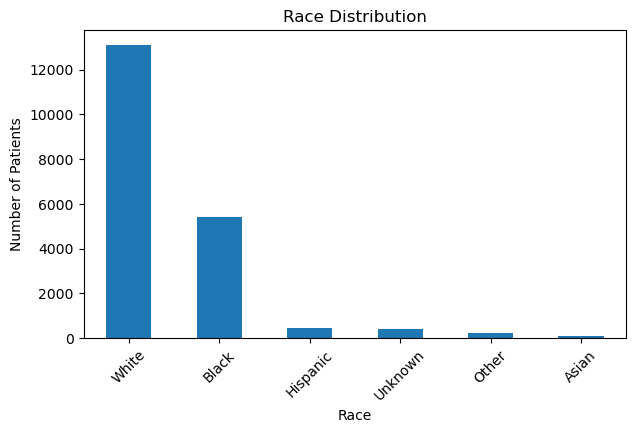

In [46]:
plt.figure(figsize=(7,4))
df["race"].value_counts().plot(kind="bar")

plt.title("Race Distribution")
plt.xlabel("Race")
plt.ylabel("Number of Patients")
plt.xticks(rotation=45)

plt.show()

### Demographic Findings

The diabetic inpatient population was primarily composed of **older adults, with patients aged 55, 65, and 75 years representing the largest age groups**. This aligns with the increased prevalence of type 2 diabetes and diabetes-related complications among older populations.

**Gender distribution was relatively balanced, with females representing approximately 54% of the population and males representing approximately 46%.**

The majority of patients identified as White (**approximately 67%**), followed by Black patients (**approximately 27%**). Other racial groups represented smaller proportions of the dataset.

These demographic characteristics describe the overall patient population; however, demographic factors alone may not fully explain hospital readmission risk. Additional analyses will examine clinical characteristics, healthcare utilization patterns, and diabetes management indicators associated with readmission outcomes.

### Demographic Cohort Stratification

In [47]:
df_grouped = (
    df.groupby(["age", "race", "gender"])
      .size()
      .reset_index(name="total_patients")
      .sort_values("total_patients", ascending=False)
)

df_grouped.head(10)

,age,race,gender,total_patients
88,75,White,Female,1472
89,75,White,Male,1281
77,65,White,Male,1269
76,65,White,Female,1227
65,55,White,Male,1212
64,55,White,Female,1203
100,85,White,Female,1129
53,45,White,Male,898
52,45,White,Female,768
101,85,White,Male,750


### Demographic Cohort Stratification Summary

A stratified analysis was performed using age, race, and gender to examine the composition of the diabetic inpatient cohort.

The highest frequency groups consisted primarily of older adults, particularly patients aged 55–75 years. White patients represented the largest racial group within the dataset, with both male and female patients contributing substantially to the highest-volume demographic combinations.

Because this dataset contains hospital encounters rather than only unique individuals, these patterns reflect healthcare utilization within the cohort and may include patients with multiple admissions.

## 6.2 Hospital Utilization Analysis

In [48]:
df["time_in_hospital"].value_counts().sort_index()

time_in_hospital
1     3236
2     4186
3     3626
4     2625
5     1771
6     1227
7      920
8      627
9      414
10     345
11     232
12     210
13     149
14     121
Name: count, dtype: int64

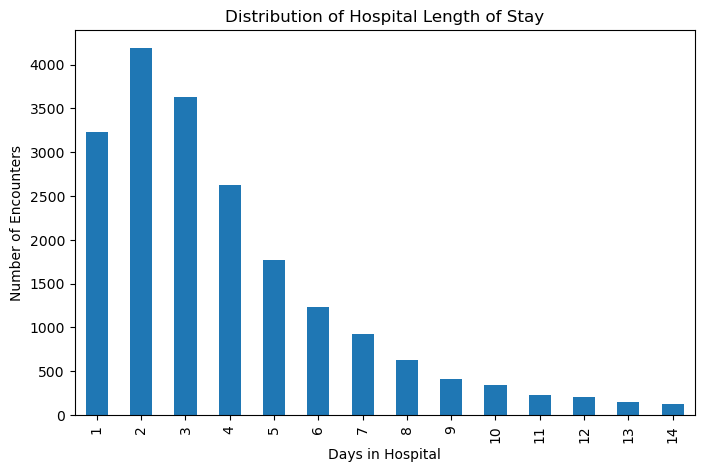

In [49]:
plt.figure(figsize=(8,5))

df["time_in_hospital"].value_counts().sort_index().plot(kind="bar")

plt.title("Distribution of Hospital Length of Stay")
plt.xlabel("Days in Hospital")
plt.ylabel("Number of Encounters")

plt.show()

### Hospital Utilization (Length of Stay)

Hospital length of stay demonstrated a right-skewed distribution, with the majority of diabetes-related admissions lasting between **1 and 4 days**.

Longer hospitalizations became progressively less frequent, suggesting that most encounters represented shorter acute care episodes, while a smaller group of patients required extended inpatient resources.

Length of stay was examined as a potential indicator of clinical complexity and healthcare utilization patterns that may contribute to future readmission risk.

In [50]:
df["time_in_hospital"] = pd.to_numeric(df["time_in_hospital"], errors='coerce')
df["time_in_hospital"].mean()
df["time_in_hospital"].median()
df["time_in_hospital"].mode()

0    2
Name: time_in_hospital, dtype: int64

### Most Common Length of Stay

Summary statistics were calculated to understand typical hospitalization duration.

**The distribution of hospital length of stay shows that most diabetes-related admissions were relatively short, with the most common hospitalization lasting 2 days**. The median length of stay represents a typical admission, while the mean is slightly higher due to a smaller number of patients with longer hospitalizations.

The difference between the mean and median suggests a right-skewed distribution, where a subset of patients required extended inpatient care.

## Total Patients Per Visit 

In [51]:
visits_per_patient = df.groupby("patient_nbr")["encounter_id"].count()
visits_per_patient.head()

patient_nbr
135     1
927     1
1152    3
1314    2
5220    1
Name: encounter_id, dtype: int64

## How many patients had 1, 2, or 3+ visits?

In [52]:
visits_per_patient.value_counts().sort_index()

visits_per_patient.mean()
visits_per_patient.median()
visits_per_patient.mode()

0    1
Name: encounter_id, dtype: int64

### Patient-Level Healthcare Utilization

Patient-level utilization was evaluated by calculating the number of hospital encounters associated with each patient identifier.

This analysis identifies patients with repeated healthcare interactions and helps characterize high-utilization patterns within the diabetic inpatient population.

Most patients had a single observed hospitalization, while a smaller subgroup experienced multiple admissions. These frequent utilizers represent an important population for readmission risk modeling because repeated hospital encounters may indicate increased clinical complexity or unmet healthcare needs.

## High Utilization Patients (3+ visits)

In [53]:
high_utilizers = visits_per_patient[visits_per_patient >= 3]
len(high_utilizers)

visits_per_patient.head()

visits_per_patient.describe()

visits_per_patient.value_counts().sort_index()

encounter_id
1     14482
2      1428
3       341
4       112
5        59
6        25
7        12
8         8
9         2
10        5
11        5
13        3
14        1
15        1
16        1
17        2
20        1
26        1
Name: count, dtype: int64

### High Utilizer Identification

Patients with three or more observed hospital encounters were classified as high utilizers.

Within the study cohort, **579 patients met this high-utilization threshold**. Although this group represents a smaller proportion of the overall population, these patients may represent individuals with increased healthcare needs, greater disease complexity, or challenges with chronic disease management.

Identifying high-utilization patterns is important because previous healthcare utilization may provide valuable information for predicting future diabetes-related readmissions.

## Add visit count back to dataset

In [54]:
df["total_visits_per_patient"] = df.groupby("patient_nbr")["encounter_id"].transform("count")
df.head()

,encounter_id,patient_nbr,race,gender,age,admission_type_id,admission_source_id,time_in_hospital,number_lab_procedures,number_procedures,...,max_glu_serum,a1c_result,insulin,change_medication,diabetes_medication,readmitted,diag_1_group,diag_2_group,diag_3_group,total_visits_per_patient
0,16680,42519267,White,Male,45,1,7,1,51,0,...,None,None,Steady,Ch,Yes,NO,Other,Other,Diabetes,1
1,28236,89869032,Black,Female,45,1,7,9,47,2,...,None,None,Steady,No,Yes,>30,Diabetes,Hypertension,Other,1
2,40926,85504905,White,Female,45,1,7,7,60,0,...,None,None,Down,Ch,Yes,<30,Other,Diabetes,Diabetes,2
3,63768,114882984,White,Male,75,1,7,5,73,0,...,None,None,No,No,Yes,>30,Other,Other,Diabetes,1
4,64410,86047875,Black,Female,25,1,7,2,11,5,...,None,None,No,No,Yes,NO,Other,Diabetes,Other,1


## Creating Patient-Level Utilization Features

Healthcare utilization history can provide important information about future readmission risk.

To incorporate prior healthcare use into the predictive model, the total number of observed hospital encounters was calculated for each patient and added back to the main dataset.

This feature represents the patient's overall healthcare utilization burden within the available dataset.

## Validating Patient Visit Count Feature

Before using patient-level utilization features in predictive modeling, the distribution of the newly created visit count variable was reviewed.

This validation step confirms that the feature was created correctly and that the number of encounters per patient aligns with the previously calculated patient-level utilization analysis.
Understanding the distribution of healthcare utilization is important because prior hospital encounters may provide predictive information about future readmission risk.

# Check distribution of total visits per patient

In [55]:
df["total_visits_per_patient"].value_counts().sort_index()

total_visits_per_patient
1     14482
2      2856
3      1023
4       448
5       295
6       150
7        84
8        64
9        18
10       50
11       55
13       39
14       14
15       15
16       16
17       34
20       20
26       26
Name: count, dtype: int64

### Feature Validation Check Interpretation

The distribution confirms that the patient visit count feature was successfully added to the dataset.

Most patients had a smaller number of observed encounters, while a smaller group of patients had multiple hospital visits, representing higher healthcare utilization patterns.

These utilization differences support the inclusion of prior healthcare use as a potential predictor of diabetes-related readmission risk.

## 6.3 Clinical Risk Factor Analysis

Clinical variables provide important information about diabetes severity and disease management. This section examines laboratory and treatment-related features that may be associated with early hospital readmission.

The following clinical features are evaluated:

- Hemoglobin A1C results
- Maximum glucose serum measurements
- Insulin therapy changes
- Medication changes

These variables may capture differences in diabetes control and treatment complexity that influence readmission risk.   

## Distribution of A1C results

In [56]:
df["a1c_result"].value_counts()

a1c_result
None    14736
>8       3092
Norm     1075
>7        786
Name: count, dtype: int64

## Distribution of maximum glucose serum results

In [57]:
df["max_glu_serum"].value_counts()

max_glu_serum
None    19344
>300      177
Norm      116
>200       52
Name: count, dtype: int64

## Visualize A1C distribution

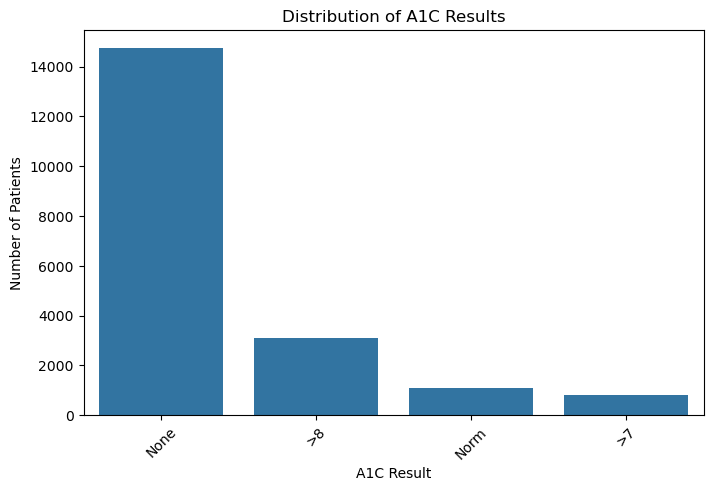

In [58]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="a1c_result"
)

plt.title("Distribution of A1C Results")
plt.xlabel("A1C Result")
plt.ylabel("Number of Patients")
plt.xticks(rotation=45)

plt.show()

## Visualize glucose serum distribution

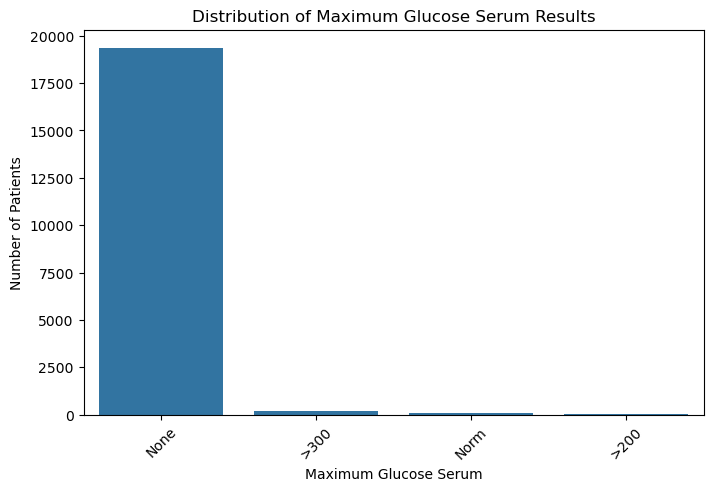

In [59]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="max_glu_serum"
)

plt.title("Distribution of Maximum Glucose Serum Results")
plt.xlabel("Maximum Glucose Serum")
plt.ylabel("Number of Patients")
plt.xticks(rotation=45)

plt.show()

## Clinical Feature Interpretation

The distributions of A1C and glucose measurements were reviewed to understand the available clinical information within the dataset.

These variables were retained as potential predictive features because they represent aspects of diabetes management and glycemic control. Poor glucose regulation may contribute to increased healthcare utilization and higher risk of complications requiring hospital readmission.

# Part 7. Outcome Definition

The original readmission outcome variable (`readmitted`) contained three categories:

- NO: No readmission within 30 days
- >30: Readmission occurring after 30 days
- <30: Readmission occurring within 30 days

For this machine learning task, the outcome was transformed into a binary classification target (`readmission_flag`) focused on predicting early hospital readmission risk.

Patients with a readmission within 30 days were classified as positive cases:

- Readmission within 30 days (<30) = 1
- No readmission within 30 days (NO or >30) = 0

This transformation converts the problem into a binary classification task, allowing predictive modeling of early diabetes-related hospital readmission risk.

### 7.1 Distribution of Readmission Outcome

Before developing predictive models, the distribution of the target variable was evaluated to assess class balance.

In this cohort of emergency diabetes-related hospital encounters, early readmission events (<30 days) represented a smaller proportion of cases compared with patients who were not readmitted within 30 days.

Healthcare prediction problems frequently contain imbalanced outcomes because clinically important events occur less frequently than routine outcomes. Therefore, model performance was evaluated using metrics beyond accuracy, including precision, recall, F1-score, and ROC-AUC.

In [60]:
df["readmitted"].value_counts()

readmitted
NO     10518
>30     6940
<30     2231
Name: count, dtype: int64

## Binary Outcome Transformation

For the machine learning task, the original three-class readmission outcome was converted into a binary classification target.

Patients with a readmission within 30 days were classified as positive cases:

- Readmission within 30 days (<30) = 1
- No readmission within 30 days (NO or >30) = 0

This transformation allows the model to focus on predicting early hospital readmission risk, which is clinically important for identifying patients who may benefit from additional intervention.

In [61]:
df["readmission_flag"] = df["readmitted"].apply(
    lambda x: 1 if x == "<30" else 0
)

## Verify New Target Variable

In [62]:
df["readmission_flag"].value_counts()

readmission_flag
0    17458
1     2231
Name: count, dtype: int64

## Readmission Outcome Distribution

After creating the binary outcome variable, the distribution of the target classes was examined to evaluate class balance.

Healthcare prediction problems often contain imbalanced outcomes because clinically important events occur less frequently than routine outcomes.

Understanding the class distribution is important because model performance should be evaluated using metrics such as recall, precision, F1-score, and ROC-AUC rather than accuracy alone.

In [63]:
df["readmission_flag"].value_counts(normalize=True).mul(100).round(2)

readmission_flag
0    88.67
1    11.33
Name: proportion, dtype: float64

### Visualize Classes

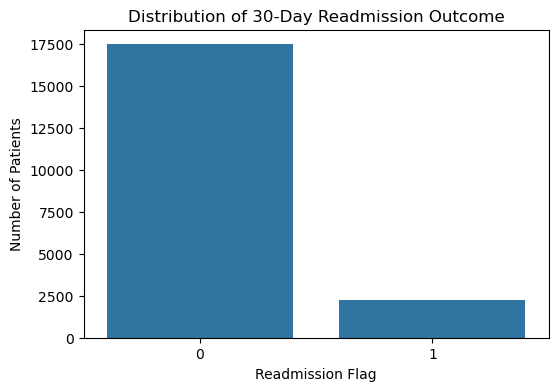

In [64]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="readmission_flag"
)

plt.title("Distribution of 30-Day Readmission Outcome")
plt.xlabel("Readmission Flag")
plt.ylabel("Number of Patients")

plt.show()

## Outcome Distribution Interpretation

The original readmission outcome contained three categories:

- No readmission (NO): 10,518 encounters
- Readmission after 30 days (>30): 6,940 encounters
- Readmission within 30 days (<30): 2,231 encounters

For machine learning, the outcome was transformed into a binary classification target (`readmission_flag`), where encounters with readmission within 30 days were labeled as positive cases.

After transformation:

- No 30-day readmission (0): **17,458 encounters (88.67%)**
- 30-day readmission (1):**2,231 encounters (11.33%)**

**The target variable demonstrates class imbalance, with early readmissions representing a smaller proportion of hospital encounters.** This reflects a common challenge in healthcare prediction tasks, where clinically important events occur less frequently than routine outcomes.

Due to this imbalance, future machine learning models will be evaluated using metrics that better assess minority class performance, including precision, recall, F1-score, and ROC-AUC rather than accuracy alone.

# Part 8. Readmission Risk Analysis

This section evaluates factors associated with 30-day hospital readmission.

Potential risk factors are examined across three categories:

- Demographic characteristics
- Healthcare utilization patterns
- Clinical diabetes-related factors

The purpose of this analysis is to identify patterns associated with readmission risk and guide feature selection for predictive modeling.

## 8.1 Demographic Risk Factors

Demographic characteristics were evaluated to determine whether patient-level factors were associated with differences in 30-day readmission rates.

The following variables were examined:

- Age
- Gender
- Race

### Readmission rates by age group

In [65]:
pd.crosstab(
    df["age"],
    df["readmission_flag"],
    normalize="index"
) * 100

readmission_flag,0,1
age,,
5,99.047619,0.952381
15,94.272076,5.727924
25,83.228247,16.771753
35,87.331918,12.668082
45,89.023967,10.976033
55,91.141219,8.858781
65,89.039978,10.960022
75,86.792949,13.207051
85,87.779182,12.220818


### Readmission rates by gender

In [66]:
pd.crosstab(
    df["gender"],
    df["readmission_flag"],
    normalize="index"
) * 100

readmission_flag,0,1
gender,,
Female,88.053015,11.946985
Male,89.403900,10.596100


### Readmission rates by race

In [67]:
pd.crosstab(
    df["race"],
    df["readmission_flag"],
    normalize="index"
) * 100

readmission_flag,0,1
race,,
Asian,90.588235,9.411765
Black,88.685185,11.314815
Hispanic,91.071429,8.928571
Other,91.764706,8.235294
Unknown,92.731830,7.268170
White,88.383453,11.616547


## Demographic Risk Factor Interpretation

Readmission rates were compared across demographic groups to identify potential differences in early hospital readmission risk.

The observed differences between groups were relatively small, suggesting that demographic variables alone may not strongly predict 30-day readmission within this cohort.

However, these variables may still provide useful baseline patient characteristics when combined with clinical and utilization features during predictive modeling.

## 8.2 Hospital Utilization Risk Factors

Previous healthcare utilization is an important predictor of future hospital readmission.

This section evaluates utilization-related variables including:

- Prior hospital visits
- Emergency visits
- Length of hospital stay

These variables may capture disease complexity, healthcare needs, and patterns associated with increased readmission risk.

 ## Check available columns

In [68]:
df.columns.tolist()

['encounter_id',
 'patient_nbr',
 'race',
 'gender',
 'age',
 'admission_type_id',
 'admission_source_id',
 'time_in_hospital',
 'number_lab_procedures',
 'number_procedures',
 'number_medications',
 'number_emergency',
 'number_inpatient_visits',
 'diag_1',
 'diag_2',
 'diag_3',
 'number_diagnoses',
 'max_glu_serum',
 'a1c_result',
 'insulin',
 'change_medication',
 'diabetes_medication',
 'readmitted',
 'diag_1_group',
 'diag_2_group',
 'diag_3_group',
 'total_visits_per_patient',
 'readmission_flag']

## Prior Inpatient Visits and Readmission

Previous inpatient utilization is a well-established indicator of patient complexity and healthcare utilization. To explore this relationship, the average number of prior inpatient visits was compared between patients who experienced a 30-day readmission and those who did not.

In [69]:
df.groupby("readmission_flag")["number_inpatient_visits"].mean()

readmission_flag
0    0.576641
1    1.446437
Name: number_inpatient_visits, dtype: float64

### Prior Inpatient Visits and Readmission Interpretation

**Patients who experienced a 30-day readmission had a substantially higher average number of prior inpatient visits (1.45) than patients who were not readmitted (0.58).** This finding suggests that patients with more frequent prior hospitalizations may be at increased risk for early readmission.

### Readmission Rate by Prior Inpatient Visits

The percentage of patients readmitted within 30 days was calculated for each level of prior inpatient visits to examine how readmission risk changes with increasing hospitalization history.

In [70]:
df.groupby("number_inpatient_visits")["readmission_flag"].mean() * 100

number_inpatient_visits
0       8.211364
1      13.503222
2      17.766854
3      19.969040
4      25.787966
5      32.240437
6      38.211382
7      31.168831
8      40.000000
9      44.444444
10     50.000000
11     75.000000
12     46.666667
13     50.000000
14     50.000000
15    100.000000
16     50.000000
19      0.000000
21    100.000000
Name: readmission_flag, dtype: float64

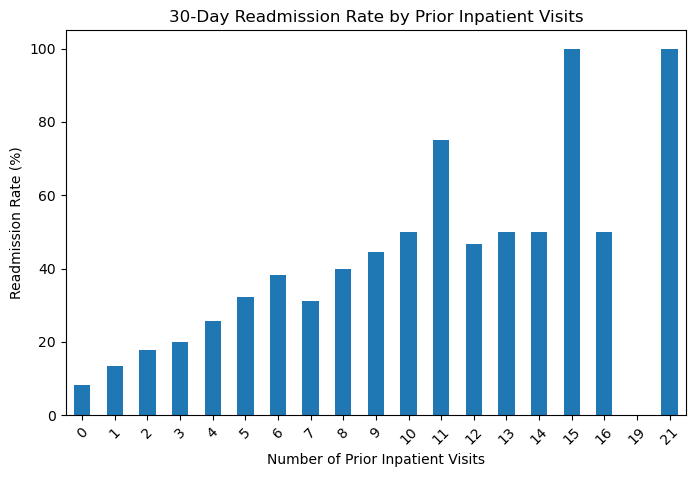

In [71]:
plt.figure(figsize=(8,5))

(
df.groupby("number_inpatient_visits")["readmission_flag"]
.mean()
.mul(100)
.plot(kind="bar")
)

plt.title("30-Day Readmission Rate by Prior Inpatient Visits")
plt.xlabel("Number of Prior Inpatient Visits")
plt.ylabel("Readmission Rate (%)")
plt.xticks(rotation=45)

plt.show()

### Readmission Rate by Prior Inpatient Visits Interpretation

Previous inpatient utilization demonstrated an association with 30-day readmission risk.

Patients with no prior inpatient visits had an observed readmission rate of approximately **8.2%**, while patients with multiple prior inpatient visits demonstrated progressively higher readmission rates.

Although higher visit categories contained fewer encounters and should be interpreted cautiously, the overall trend suggests that previous hospitalization history may identify patients with greater healthcare needs and increased risk of early readmission.

Because healthcare utilization variables demonstrated meaningful relationships with readmission outcomes, inpatient and emergency visit features were included in the machine learning dataset.

### Total Hospital Encounters per Patient

Overall healthcare utilization was further evaluated by comparing the average number of hospital encounters per patient between the two readmission groups.

In [72]:
df.groupby("readmission_flag")["total_visits_per_patient"].mean()

readmission_flag
0    1.510368
1    2.809054
Name: total_visits_per_patient, dtype: float64

### Total Hospital Encounters per Patient

Patients who experienced a 30-day readmission averaged **2.81 hospital encounters**, compared with **1.51 encounters among patients who were not readmitted**.

This finding suggests that higher healthcare utilization was associated with increased early readmission risk.

## Readmission rate by emergency Patient

In [73]:
df.groupby(
    "number_emergency"
)["readmission_flag"].mean() * 100

number_emergency
0      10.441860
1      14.469453
2      18.046709
3      25.423729
4      26.470588
5      29.032258
6      31.250000
7      29.166667
8      31.818182
9      11.111111
10     30.769231
11     33.333333
12     25.000000
13     40.000000
16      0.000000
20    100.000000
22      0.000000
24      0.000000
25      0.000000
42      0.000000
Name: readmission_flag, dtype: float64

## Readmission rate by length of stay

In [74]:
df.groupby(
    "time_in_hospital"
)["readmission_flag"].mean() * 100

time_in_hospital
1      8.652658
2      9.197324
3     10.838389
4     12.304762
5     13.156409
6     13.610432
7     13.804348
8     16.427432
9     11.594203
10    17.971014
11    13.793103
12    17.619048
13    14.093960
14    16.528926
Name: readmission_flag, dtype: float64

### Hospital Utilization Factors Interpretation

Hospital utilization variables demonstrated meaningful relationships with 30-day readmission risk.

Patients who experienced a 30-day readmission had higher prior inpatient utilization compared with patients who were not readmitted. The average number of prior inpatient visits was higher among readmitted patients **(1.45 visits) compared with non-readmitted patients (0.58 visits)**. Additionally, patients with a 30-day readmission had a higher average number of total hospital encounters per patient **(2.81 vs. 1.51)**.

Readmission rates generally increased as prior inpatient visits and emergency department visits increased. Patients with more frequent emergency visits demonstrated higher readmission rates, suggesting that repeated acute care utilization may identify patients with greater healthcare needs and increased readmission risk.

Longer hospital stays were also associated with higher readmission rates, indicating that hospitalization complexity and resource utilization may provide additional predictive information.

### Clinical Insight

These findings suggest that prior healthcare utilization patterns are important indicators of future readmission risk. Patients with frequent inpatient admissions, emergency department visits, and longer hospital stays may represent higher-risk populations who could benefit from early intervention strategies, improved discharge planning, and closer post-discharge follow-up.

These utilization-based features were therefore considered valuable predictors for subsequent machine learning models.

## 8.3 Clinical Risk Factors

Clinical diabetes-related variables were evaluated to determine whether indicators of disease management and treatment complexity were associated with 30-day readmission.

The following features were examined:

- A1C results
- Maximum glucose serum measurements
- Insulin therapy
- Medication changes

### A1C Readmission Rates

In [75]:
pd.crosstab(
    df["a1c_result"],
    df["readmission_flag"],
    normalize="index"
) * 100
    

readmission_flag,0,1
a1c_result,,
>7,88.931298,11.068702
>8,90.847348,9.152652
None,88.063246,11.936754
Norm,90.511628,9.488372


 ## Glucose Readmission Rates

In [76]:
pd.crosstab(
    df["max_glu_serum"],
    df["readmission_flag"],
    normalize="index"
) * 100

readmission_flag,0,1
max_glu_serum,,
>200,84.615385,15.384615
>300,84.745763,15.254237
None,88.730356,11.269644
Norm,86.206897,13.793103


## Insulin Readmission Rates

In [77]:
pd.crosstab(
    df["insulin"],
    df["readmission_flag"],
    normalize="index"
) * 100

readmission_flag,0,1
insulin,,
Down,85.591767,14.408233
No,89.642041,10.357959
Steady,89.339152,10.660848
Up,87.459677,12.540323


## Medication Change Readmission Rates

In [78]:
pd.crosstab(

    df["change_medication"],
    df["readmission_flag"],
    normalize="index"
) * 100

readmission_flag,0,1
change_medication,,
Ch,88.295709,11.704291
No,89.041096,10.958904


## Clinical Risk Factors Interpretation

Clinical variables related to diabetes management and treatment patterns showed modest differences in 30-day readmission risk.

### Glycemic Control Indicators

A1C results showed relatively small differences in readmission rates across categories. Patients without a recorded A1C value had **the highest observed readmission rate (11.94%)** compared with patients with documented A1C measurements. However, no strong relationship was observed between A1C category and 30-day readmission risk.

Maximum glucose serum measurements demonstrated higher observed readmission rates among patients with elevated glucose values. **Patients with glucose levels greater than 200 mg/dL (15.38%) and greater than 300 mg/dL (15.25%) had higher readmission rates compared with patients without recorded glucose measurements (11.27%)**. These findings suggest that acute glucose measurements during hospitalization may provide additional clinical context; however, glucose levels alone may not fully explain readmission risk.

### Medication-Related Factors

Insulin treatment categories showed differences in readmission rates. Patients with insulin dosage changes classified as **"Down"** had the highest observed readmission rate **(14.41%)**, followed by patients with insulin changes classified as **"Up"** (12.54%). **Patients with no insulin treatment had a lower readmission rate (10.36%)**. These treatment patterns may reflect differences in disease complexity, hospitalization severity, or clinical management needs.

**Medication changes demonstrated a small difference in readmission risk. Patients with medication changes had a slightly higher readmission rate (11.70%) compared with patients without medication changes (10.96%)**. This suggests that medication changes alone may have limited predictive value but may capture differences in patient treatment management.

### Clinical Insight

Overall, diabetes management indicators demonstrated modest associations with 30-day readmission risk. Variables related to glycemic measurements, insulin treatment patterns, and medication changes may reflect differences in disease severity, treatment complexity, and healthcare management needs.

Although individual clinical factors showed limited differences when examined independently, these variables may provide additional predictive value when combined with demographic characteristics, hospitalization factors, and healthcare utilization features in machine learning models.

# Part 9: Feature Engineering / ML Dataset Preparation

After completing data cleaning, validation, and exploratory analysis, the dataset was prepared for machine learning modeling.

Feature engineering was performed to create clinically meaningful predictors that capture patient characteristics and healthcare utilization patterns.

## Patient-Level Utilization Feature Engineering

Healthcare utilization history may provide important information about future readmission risk.

A patient-level utilization feature was created by calculating the total number of encounters associated with each patient using `patient_nbr`. The current hospitalization encounter was then removed by subtracting one from the total encounter count to create `prior_visits`.

This engineered feature captures previous healthcare utilization patterns while reducing the risk of including information from the current admission in the prediction process.

In [79]:
df["prior_visits"] = (
    df["total_visits_per_patient"] - 1
)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19689 entries, 0 to 19688
Data columns (total 29 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   encounter_id              19689 non-null  int64 
 1   patient_nbr               19689 non-null  int64 
 2   race                      19689 non-null  object
 3   gender                    19689 non-null  object
 4   age                       19689 non-null  int64 
 5   admission_type_id         19689 non-null  object
 6   admission_source_id       19689 non-null  object
 7   time_in_hospital          19689 non-null  int64 
 8   number_lab_procedures     19689 non-null  int64 
 9   number_procedures         19689 non-null  int64 
 10  number_medications        19689 non-null  int64 
 11  number_emergency          19689 non-null  int64 
 12  number_inpatient_visits   19689 non-null  int64 
 13  diag_1                    19689 non-null  object
 14  diag_2                

In [80]:
df[
    ["patient_nbr",
     "total_visits_per_patient",
     "prior_visits"]
].head()

,patient_nbr,total_visits_per_patient,prior_visits
0,42519267,1,0
1,89869032,1,0
2,85504905,2,1
3,114882984,1,0
4,86047875,1,0


### Prior Visits Feature Evaluation

A patient-level utilization feature (`prior_visits`) was engineered to represent previous healthcare encounters before the current hospitalization.

This feature demonstrated potential predictive value because patients with repeated hospital encounters may represent individuals with higher disease complexity or increased healthcare needs.

However, `prior_visits` was excluded from the final machine learning dataset because encounter timestamps were unavailable to verify that these previous encounters occurred before the prediction point. Removing this feature reduced the risk of incorporating future information into model training and improved the reliability of the predictive modeling workflow.

In [81]:
ml_features = [
    "age",
    "number_inpatient_visits",
    "number_emergency",
    "time_in_hospital",
    "a1c_result",
    "max_glu_serum",
    "insulin",
    "change_medication",
]

X = df[ml_features]

y = df["readmission_flag"]

In [82]:
X = pd.get_dummies(
    X,
    columns=[
        "a1c_result",
        "max_glu_serum",
        "insulin",
        "change_medication"
    ],
    drop_first=False
)

## Saving the Final Machine Learning Dataset

The final machine learning dataset was saved to preserve the exact data structure used during model development.

This dataset includes the engineered clinical features, encoded categorical variables, and the binary target variable (`readmission_flag`) used for predicting 30-day diabetes readmission risk.

Saving the final ML dataset improves reproducibility and allows the modeling workflow to be recreated or extended in future analyses.

In [83]:
ml_dataset = X.copy()

ml_dataset["readmission_flag"] = y

ml_dataset.to_csv(
    "diabetes_final_ml_dataset.csv",
    index=False
)

## Final Machine Learning Dataset

After feature selection and encoding, the final machine learning dataset contained 19,689 hospital encounters and 14 predictor variables.

The final predictors included demographic characteristics, diabetes-related clinical indicators, and healthcare utilization measures:

- Age
- Prior inpatient utilization
- Emergency department utilization
- Length of hospital stay
- A1C measurement category
- Maximum glucose measurement category
- Insulin treatment status
- Medication changes

Categorical variables were converted into numerical representations using one-hot encoding to prepare the data for machine learning algorithms.

The target variable (`readmission_flag`) was retained separately as the binary outcome for predicting 30-day hospital readmission risk.

In [84]:
X.shape

(19689, 18)

In [85]:
X.head()

,age,number_inpatient_visits,number_emergency,time_in_hospital,a1c_result_>7,a1c_result_>8,a1c_result_None,a1c_result_Norm,max_glu_serum_>200,max_glu_serum_>300,max_glu_serum_None,max_glu_serum_Norm,insulin_Down,insulin_No,insulin_Steady,insulin_Up,change_medication_Ch,change_medication_No
0,45,0,0,1,False,False,True,False,False,False,True,False,False,False,True,False,True,False
1,45,0,0,9,False,False,True,False,False,False,True,False,False,False,True,False,False,True
2,45,0,1,7,False,False,True,False,False,False,True,False,True,False,False,False,True,False
3,75,0,0,5,False,False,True,False,False,False,True,False,False,True,False,False,False,True
4,25,1,0,2,False,False,True,False,False,False,True,False,False,True,False,False,False,True


## Feature Engineering/ML Preparation Interpretation

Clinical and utilization variables were transformed into a machine learning-ready format while maintaining their clinical meaning.

A binary target variable (`readmission_flag`) was created to classify patients based on whether they experienced a readmission within 30 days.

A prior utilization feature (`prior_visits`) was engineered to represent previous healthcare encounters while avoiding leakage from the current hospitalization.

Categorical clinical variables, including A1C results, glucose measurements, insulin treatment, and medication changes, were converted into numerical features using one-hot encoding.

The final feature matrix (`X`) and target variable (`y`) are now prepared for machine learning model development and evaluation.

# Part 10: Machine Learning Modeling

After completing data cleaning, feature engineering, and exploratory analysis, machine learning models were developed to predict whether a patient with diabetes would experience readmission within 30 days after discharge.

The objective is to compare supervised classification algorithms and determine which model provides the best ability to identify patients at increased risk of early readmission.

Because the dataset contains an imbalanced outcome, model evaluation will focus on:

- Precision
- Recall
- F1-score
- ROC-AUC

These metrics provide a better understanding of model performance than accuracy alone, particularly for identifying minority-class patients who experience readmission.

## 10.1 Training and Testing Dataset Split

The models were trained using the same feature set to allow direct comparison of predictive performance.

In [86]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [87]:
X_train.shape, X_test.shape

((15751, 18), (3938, 18))

In [88]:
y_train.value_counts(normalize=True)

y_test.value_counts(normalize=True)

readmission_flag
0    0.886745
1    0.113255
Name: proportion, dtype: float64

## Training and Testing Dataset Validation

The dataset was split into training and testing subsets while maintaining the original class distribution through stratified sampling.

The training dataset contained **15,751 encounters**, while the testing dataset contained **3,938 encounters**. Both datasets maintained a similar proportion of readmitted and non-readmitted cases:

- Non-readmitted encounters: **approximately 88.7%**
- 30-day readmission encounters: **approximately 11.3%**

Maintaining consistent class distribution between the training and testing datasets helps ensure that model evaluation reflects real-world performance and reduces bias caused by an uneven split of the target outcome.

### Model Development

Three supervised classification models were developed to predict 30-day diabetes readmission risk:

- Logistic Regression
- Random Forest
- XGBoost

Logistic Regression was selected because of its interpretability and ability to identify relationships between clinical features and readmission risk.

Random Forest was included because it can capture nonlinear relationships and feature interactions.

XGBoost was included as a gradient boosting approach commonly used for structured healthcare datasets.

In [89]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

log_model.fit(
    X_train,
    y_train
)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [90]:
log_predictions = log_model.predict(X_test)

In [91]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced"
)

rf.fit(
    X_train,
    y_train
)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [92]:
rf_predictions = rf.predict(X_test)

In [93]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    random_state=42,
    eval_metric="logloss",
    scale_pos_weight=7.8
)

xgb_model.fit(
    X_train,
    y_train
)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,'logloss'


In [94]:
xgb_predictions = xgb_model.predict(X_test)

## Model Training Summary

Three supervised classification models were developed to predict 30-day diabetes readmission risk:

- Logistic Regression
- Random Forest
- XGBoost

Because the dataset contained an imbalanced outcome, imbalance correction methods were applied during training. Logistic Regression and Random Forest used class weighting, while XGBoost used the `scale_pos_weight` parameter based on the ratio of non-readmitted to readmitted encounters.

The trained models were then evaluated using precision, recall, F1-score, and ROC-AUC to determine their ability to identify patients at risk for early readmission.

## 10.3 Model Evaluation

Model performance was evaluated using metrics that are appropriate for an imbalanced healthcare classification problem.

Accuracy alone can be misleading because the majority of encounters did not result in readmission. Therefore, evaluation focused on:

- Precision: Ability to correctly identify true readmissions among predicted readmissions
- Recall: Ability to identify patients who actually experienced readmission
- F1-score: Balance between precision and recall
- ROC-AUC: Overall ability of the model to distinguish between readmitted and non-readmitted encounters


In [95]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

In [96]:

log_predictions = log_model.predict(X_test)


log_probabilities = log_model.predict_proba(X_test)[:, 1]


print("Logistic Regression")
print(classification_report(y_test, log_predictions))

print("ROC-AUC:",
      roc_auc_score(y_test, log_probabilities))

Logistic Regression
              precision    recall  f1-score   support

           0       0.92      0.72      0.81      3492
           1       0.19      0.51      0.28       446

    accuracy                           0.70      3938
   macro avg       0.55      0.62      0.54      3938
weighted avg       0.84      0.70      0.75      3938

ROC-AUC: 0.6719895314851627


In [97]:

rf_predictions = rf.predict(X_test)


rf_probabilities = rf.predict_proba(X_test)[:, 1]


print("Random Forest")
print(classification_report(y_test, rf_predictions))

print("ROC-AUC:",
      roc_auc_score(y_test, rf_probabilities))

Random Forest
              precision    recall  f1-score   support

           0       0.89      0.86      0.87      3492
           1       0.13      0.17      0.15       446

    accuracy                           0.78      3938
   macro avg       0.51      0.51      0.51      3938
weighted avg       0.80      0.78      0.79      3938

ROC-AUC: 0.5325439569753286


In [98]:

xgb_predictions = xgb_model.predict(X_test)

xgb_probabilities = xgb_model.predict_proba(X_test)[:, 1]


print("XGBoost")
print(classification_report(y_test, xgb_predictions))

print("ROC-AUC:",
      roc_auc_score(y_test, xgb_probabilities))

XGBoost
              precision    recall  f1-score   support

           0       0.91      0.72      0.80      3492
           1       0.16      0.42      0.23       446

    accuracy                           0.68      3938
   macro avg       0.53      0.57      0.52      3938
weighted avg       0.82      0.68      0.74      3938

ROC-AUC: 0.5897220552807443


## 10.3.1 Confusion Matrix Evaluation

A confusion matrix was used to further evaluate model performance by examining correct and incorrect predictions.

For healthcare prediction tasks, false negatives are especially important because they represent patients who experienced readmission but were not identified as high risk by the model.

Evaluating false negatives helps assess the model's ability to identify patients who may benefit from additional clinical intervention.

<Figure size 600x500 with 0 Axes>

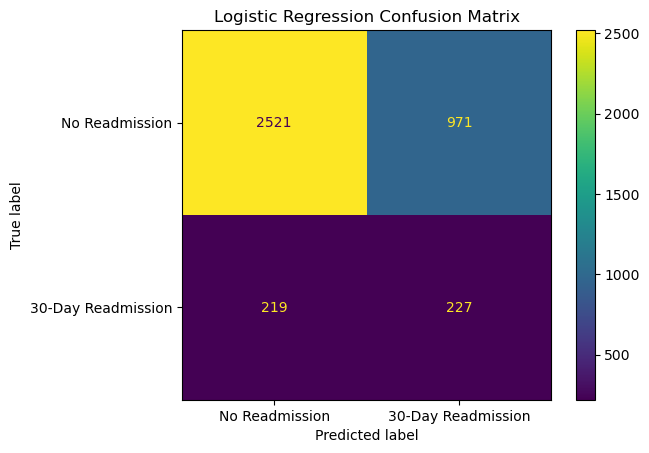

In [99]:
from sklearn.metrics import ConfusionMatrixDisplay

plt.figure(figsize=(6,5))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    log_predictions,
    display_labels=["No Readmission", "30-Day Readmission"]
)

plt.title("Logistic Regression Confusion Matrix")

plt.show()

### Confusion Matrix Interpretation

The confusion matrix demonstrates the model's ability to distinguish between patients who were not readmitted and patients who experienced a 30-day readmission.

The model correctly identified a proportion of true readmission cases; however, some false negatives remained, indicating that certain high-risk patients were not detected.

In a clinical setting, reducing false negatives may be important because missed high-risk patients could represent opportunities for improved follow-up care and intervention.

## 10.4 Model Comparison

The performance of logistic regression, random forest, and XGBoost was compared using evaluation metrics appropriate for an imbalanced healthcare classification problem.

Because the goal of this project is to identify patients at risk for 30-day readmission, greater emphasis was placed on recall, F1-score, and ROC-AUC rather than accuracy alone.

The comparison below summarizes the ability of each model to distinguish between readmitted and non-readmitted patients.

In [100]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],
    "Accuracy": [
        accuracy_score(y_test, log_predictions),
        accuracy_score(y_test, rf_predictions),
        accuracy_score(y_test, xgb_predictions)
    ],
    "Precision": [
        precision_score(y_test, log_predictions),
        precision_score(y_test, rf_predictions),
        precision_score(y_test, xgb_predictions)
    ],
    "Recall": [
        recall_score(y_test, log_predictions),
        recall_score(y_test, rf_predictions),
        recall_score(y_test, xgb_predictions)
    ],
    "F1 Score": [
        f1_score(y_test, log_predictions),
        f1_score(y_test, rf_predictions),
        f1_score(y_test, xgb_predictions)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, log_probabilities),
        roc_auc_score(y_test, rf_probabilities),
        roc_auc_score(y_test, xgb_probabilities)
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.697816,0.189482,0.508969,0.276156,0.671990
1,Random Forest,0.781107,0.132509,0.168161,0.148221,0.532544
2,XGBoost,0.683596,0.159284,0.419283,0.230864,0.589722


## Model Selection Interpretation

The three models demonstrated different performance characteristics.

Random Forest achieved the highest overall accuracy; however, it showed limited ability to identify patients who experienced a 30-day readmission. This indicates that the model performed well at identifying the majority class but struggled with the minority readmission class.

Logistic regression demonstrated the strongest performance for identifying readmitted patients, achieving the highest recall, F1-score, and ROC-AUC among the evaluated models.

Logistic regression was selected as the preferred model because the objective of this project was to identify patients at increased risk for readmission rather than maximize overall classification accuracy. In healthcare prediction problems, identifying potential high-risk patients is often more valuable than simply predicting the most common outcome.

## 10.5 Feature Importance and Clinical Interpretation

After selecting the best-performing model, feature interpretation was performed to understand which clinical and utilization variables contributed most to predicting 30-day readmission risk.

In healthcare applications, understanding model drivers is important because predictive performance alone does not provide insight into why a model makes a prediction. Examining feature contributions helps determine whether the model identifies clinically meaningful patterns.

In [101]:
log_coefficients = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": log_model.coef_[0]
})

log_coefficients = log_coefficients.sort_values(
    by="Coefficient",
    ascending=False
)

log_coefficients.head(10)

,Feature,Coefficient
1,number_inpatient_visits,0.292741
2,number_emergency,0.084359
12,insulin_Down,0.061604
3,time_in_hospital,0.057016
0,age,0.006534
15,insulin_Up,0.004333
4,a1c_result_>7,0.002885
6,a1c_result_None,-0.020818
8,max_glu_serum_>200,-0.021855
11,max_glu_serum_Norm,-0.027503


In [102]:
log_coefficients.sort_values(
    by="Coefficient",
    ascending=True
).head(10)

,Feature,Coefficient
16,change_medication_Ch,-0.238753
5,a1c_result_>8,-0.222400
14,insulin_Steady,-0.215095
13,insulin_No,-0.213933
10,max_glu_serum_None,-0.172163
9,max_glu_serum_>300,-0.141570
17,change_medication_No,-0.124339
7,a1c_result_Norm,-0.122758
11,max_glu_serum_Norm,-0.027503
8,max_glu_serum_>200,-0.021855


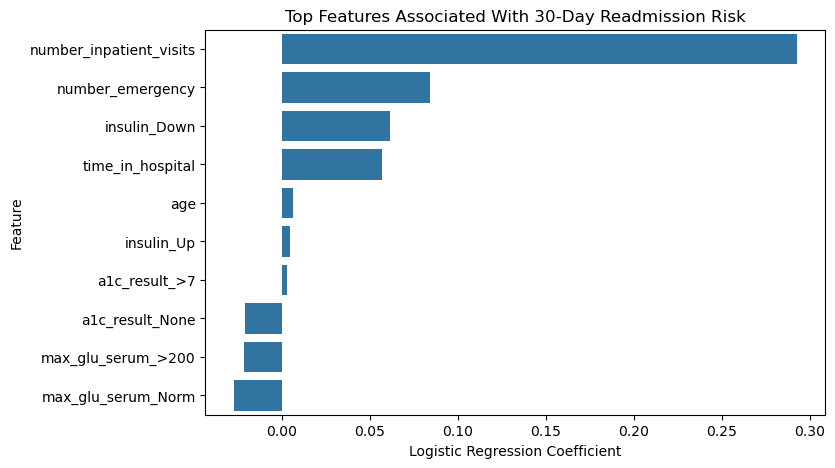

In [103]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=log_coefficients.head(10),
    x="Coefficient",
    y="Feature"
)

plt.title("Top Features Associated With 30-Day Readmission Risk")
plt.xlabel("Logistic Regression Coefficient")
plt.ylabel("Feature")

plt.show()

In [104]:
log_coefficients.head(10)

,Feature,Coefficient
1,number_inpatient_visits,0.292741
2,number_emergency,0.084359
12,insulin_Down,0.061604
3,time_in_hospital,0.057016
0,age,0.006534
15,insulin_Up,0.004333
4,a1c_result_>7,0.002885
6,a1c_result_None,-0.020818
8,max_glu_serum_>200,-0.021855
11,max_glu_serum_Norm,-0.027503


In [105]:
log_coefficients.sort_values(
    by="Coefficient",
    ascending=True
).head(10)

,Feature,Coefficient
16,change_medication_Ch,-0.238753
5,a1c_result_>8,-0.222400
14,insulin_Steady,-0.215095
13,insulin_No,-0.213933
10,max_glu_serum_None,-0.172163
9,max_glu_serum_>300,-0.141570
17,change_medication_No,-0.124339
7,a1c_result_Norm,-0.122758
11,max_glu_serum_Norm,-0.027503
8,max_glu_serum_>200,-0.021855


## Clinical Interpretation of Logistic Regression Features

Overall, the Logistic Regression model identified healthcare utilization patterns as the strongest contributors to 30-day readmission prediction. In particular, inpatient visits, emergency visits, and length of hospital stay showed positive associations with predicted readmission risk, suggesting that prior healthcare burden and hospitalization intensity are important signals for identifying higher-risk patients.

These findings align with clinical expectations that patients with greater healthcare utilization and more complex care needs may benefit from additional monitoring and follow-up after discharge. However, these relationships represent predictive associations rather than causal effects and should not be interpreted as direct causes of readmission.

# Part 11: Model Limitations and Future Improvements

## Modeling Limitations

The dataset exhibited class imbalance, as patients readmitted within 30 days represented a smaller proportion of encounters. This imbalance may have affected the model’s ability to identify readmissions accurately.

Model performance may improve through hyperparameter tuning, threshold adjustment, cross-validation, and additional imbalance-handling techniques.

The dataset represents historical hospital encounters from 1999–2008 and may not reflect current healthcare practices. External validation using an independent healthcare dataset would be necessary before any clinical deployment.

This model is intended for educational and research purposes and should support—not replace—clinical judgment.

## Future Improvements

Future work could evaluate additional feature-engineering approaches, optimize model hyperparameters, tune the decision threshold, assess calibration, and validate the model using an independent healthcare dataset.

# Part 12: Project Conclusion

## Final Recommendation

Logistic Regression was selected as the final model because it achieved the highest **ROC-AUC (0.672)** while remaining interpretable. The model demonstrated moderate ability to distinguish 30-day readmissions from non-readmissions.

Because the positive class was imbalanced and precision was low, the model should be used as an educational risk-screening example rather than a clinical decision-making tool. Future work should include threshold tuning, cross-validation, calibration assessment, and external validation.

## Saving the Final Model for Deployment

The selected Logistic Regression model was saved using joblib for future deployment.

Saving the trained model allows the predictive system to be reused without retraining and provides the foundation for creating an interactive clinical prediction application using Streamlit.

In [106]:
import joblib

joblib.dump(
    log_model,
    "diabetes_readmission_model.pkl"
)

['diabetes_readmission_model.pkl']

## Saving Model Feature Structure

The final feature list used by the model was saved to maintain consistency between model training and future predictions.

Because categorical variables were transformed using one-hot encoding, the saved feature structure ensures that new patient inputs provided during deployment are converted into the same format expected by the trained model.

This prevents feature mismatch errors and supports reliable model predictions in a Streamlit application.

In [107]:
joblib.dump(
    X.columns.tolist(),
    "model_features.pkl"
)

['model_features.pkl']

## Deployment Summary

The trained machine learning model and feature structure were successfully saved. These files allow the model to be deployed as an interactive Streamlit application while maintaining consistency between training and prediction environments.